# 📰 News Topic Classifier Using BERT
## DevelopersHub Corporation — AI/ML Engineering Internship
### Task 1: Fine-tuning BERT on AG News Dataset

**Objective:** Fine-tune `bert-base-uncased` to classify news headlines into 4 topic categories:
- 🌍 **World** — international news and geopolitics
- 🏅 **Sports** — sports events and athletes
- 💼 **Business** — economy, finance, and markets
- 🔬 **Sci/Tech** — science and technology

**Tools Used:** Hugging Face Transformers · Datasets · PyTorch · scikit-learn · Gradio

---
> ⚠️ **Google Colab Users:** Go to `Runtime → Change Runtime Type → T4 GPU` before running!

In [1]:
# ============================================================
# CELL 1 ▸ Install Required Libraries
# Run this cell FIRST, then restart the runtime before continuing
# ============================================================

!pip install transformers datasets torch scikit-learn gradio accelerate ipywidgets seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 48.7 MB/s eta 0:00:00


## Step 1 · GPU Setup & Environment Check

In [2]:
# ============================================================
# CELL 2 ▸ GPU Setup & Environment Check
# ============================================================

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")

if torch.cuda.is_available():
    print(f"   GPU Name   : {torch.cuda.get_device_name(0)}")
    print(f"   GPU Memory : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("⚠️  No GPU detected — training will be slow.")
    print("   Tip: Runtime → Change Runtime Type → GPU (T4)")

import transformers, datasets, sklearn, seaborn
print(f"\n📦 Library Versions:")
print(f"   transformers : {transformers.__version__}")
print(f"   datasets     : {datasets.__version__}")
print(f"   torch        : {torch.__version__}")
print(f"   scikit-learn : {sklearn.__version__}")
print(f"   seaborn      : {seaborn.__version__}")

✅ Using device: cuda
   GPU Name   : Tesla T4
   GPU Memory : 15.64 GB

📦 Library Versions:
   transformers : 5.0.0
   datasets     : 4.0.0
   torch        : 2.10.0+cu128
   scikit-learn : 1.6.1
   seaborn      : 0.13.2


## Step 2 · Import Libraries

In [3]:
# ============================================================
# CELL 3 ▸ Import All Required Libraries
# ============================================================

import os
import warnings
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F

# Suppress noisy warnings
warnings.filterwarnings("ignore")
logging.getLogger("datasets").setLevel(logging.ERROR)
logging.getLogger("transformers").setLevel(logging.ERROR)

# Hugging Face
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## Step 3 · Load the AG News Dataset
AG News has **120,000 training** and **7,600 test** samples across 4 balanced classes.
Loaded directly from Hugging Face Hub — no manual download needed.

In [4]:
# ============================================================
# CELL 4 ▸ Load AG News Dataset from Hugging Face
# ============================================================

print("📥 Loading AG News dataset...")
raw_dataset = load_dataset("ag_news")

label_names = raw_dataset["train"].features["label"].names

print("\n✅ Dataset loaded!")
print(f"\n📊 Structure  : {raw_dataset}")
print(f"\n🏷️  Classes   : {label_names}")
print(f"   0 → World | 1 → Sports | 2 → Business | 3 → Sci/Tech")

📥 Loading AG News dataset...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]


✅ Dataset loaded!

📊 Structure  : DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

🏷️  Classes   : ['World', 'Sports', 'Business', 'Sci/Tech']
   0 → World | 1 → Sports | 2 → Business | 3 → Sci/Tech


## Step 4 · Explore the Dataset

📋 SAMPLE TRAINING EXAMPLES

[1] Label : Business (2)
     Text  : Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ult...

[2] Label : Business (2)
     Text  : Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has...

[3] Label : Business (2)
     Text  : Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about the economy ...

[4] Label : Business (2)
     Text  : Iraq Halts Oil Exports from Main Southern Pipeline (Reuters) Reuters - Authorities have halted oil export\flow...

📊 Train : 120,000  |  Test : 7,600


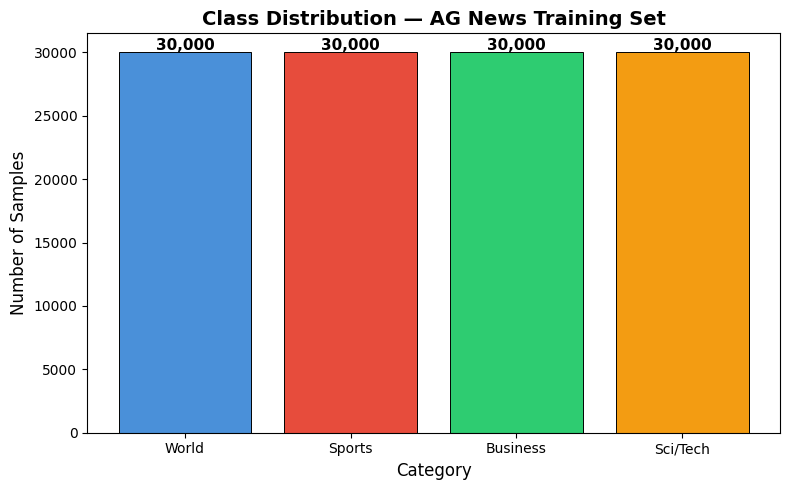


✅ Dataset is perfectly balanced — ideal for training!


In [5]:
# ============================================================
# CELL 5 ▸ Dataset Exploration & Visualization
# ============================================================

# --- Sample examples ---
print("=" * 65)
print("📋 SAMPLE TRAINING EXAMPLES")
print("=" * 65)
for i in range(4):
    s = raw_dataset["train"][i]
    print(f"\n[{i+1}] Label : {label_names[s['label']]} ({s['label']})")
    print(f"     Text  : {s['text'][:110]}...")

# --- Dataset sizes ---
print(f"\n📊 Train : {len(raw_dataset['train']):,}  |  Test : {len(raw_dataset['test']):,}")

# --- Class distribution bar chart ---
train_labels  = raw_dataset["train"]["label"]
label_counts  = pd.Series(train_labels).value_counts().sort_index()
colors        = ["#4A90D9", "#E74C3C", "#2ECC71", "#F39C12"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar([label_names[i] for i in label_counts.index],
              label_counts.values, color=colors, edgecolor="black", linewidth=0.7)
ax.set_title("Class Distribution — AG News Training Set", fontsize=14, fontweight="bold")
ax.set_xlabel("Category", fontsize=12)
ax.set_ylabel("Number of Samples", fontsize=12)
for bar, count in zip(bars, label_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f"{count:,}", ha="center", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Dataset is perfectly balanced — ideal for training!")

## Step 5 · Create Training Subset *(Recommended for Speed)*
Full training set = 120,000 samples. We use **8,000 train / 2,000 test** for fast experimentation.  
Set `TRAIN_SIZE = None` to train on the full dataset for maximum accuracy.

In [6]:
# ============================================================
# CELL 6 ▸ Create Stratified Subset for Faster Training
# ============================================================

TRAIN_SIZE = 8000    # Set to None to use all 120,000 samples
TEST_SIZE  = 2000    # Set to None to use all 7,600 test samples
SEED       = 42

train_dataset = (raw_dataset["train"].shuffle(seed=SEED).select(range(TRAIN_SIZE))
                 if TRAIN_SIZE else raw_dataset["train"])

test_dataset  = (raw_dataset["test"].shuffle(seed=SEED).select(range(TEST_SIZE))
                 if TEST_SIZE else raw_dataset["test"])

print(f"✅ Train : {len(train_dataset):,} samples")
print(f"✅ Test  : {len(test_dataset):,} samples")

✅ Train : 8,000 samples
✅ Test  : 2,000 samples


## Step 6 · Tokenization
Convert raw text into **token IDs** and **attention masks** that BERT understands.
`padding=False` here — batches are padded dynamically by `DataCollatorWithPadding`.

In [7]:
# ============================================================
# CELL 7 ▸ Load Tokenizer & Tokenize Dataset
# ============================================================

MODEL_NAME = "bert-base-uncased"
MAX_LENGTH = 128   # 128 tokens is sufficient for news headlines

print(f"🔤 Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(examples):
    """Tokenize text with truncation; dynamic padding handled by DataCollator."""
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,
    )

print("⚙️  Tokenizing training set...")
tokenized_train = train_dataset.map(tokenize_fn, batched=True, remove_columns=["text"])

print("⚙️  Tokenizing test set...")
tokenized_test  = test_dataset.map( tokenize_fn, batched=True, remove_columns=["text"])

# Rename 'label' → 'labels'  (required by Hugging Face Trainer)
tokenized_train = tokenized_train.rename_column("label", "labels")
tokenized_test  = tokenized_test.rename_column( "label", "labels")

tokenized_train.set_format("torch")
tokenized_test.set_format("torch")

print("\n✅ Tokenization complete!")
print(f"\n📋 Sample keys : {list(tokenized_train[0].keys())}")
print(f"   input_ids shape : {tokenized_train[0]['input_ids'].shape}")

🔤 Loading tokenizer: bert-base-uncased


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

⚙️  Tokenizing training set...


Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

⚙️  Tokenizing test set...


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]


✅ Tokenization complete!

📋 Sample keys : ['labels', 'input_ids', 'token_type_ids', 'attention_mask']
   input_ids shape : torch.Size([35])


## Step 7 · Load Pre-trained BERT Model
`bert-base-uncased` has 110M parameters. We add a **4-class linear classification head** on top.

In [8]:
# ============================================================
# CELL 8 ▸ Load BERT for Sequence Classification
# ============================================================

id2label = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}
label2id = {v: k for k, v in id2label.items()}

print(f"🤖 Loading model: {MODEL_NAME}")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=4,
    id2label=id2label,
    label2id=label2id,
)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n✅ Model loaded!")
print(f"   Total parameters     : {total_params:,}")
print(f"   Trainable parameters : {trainable_params:,}")

🤖 Loading model: bert-base-uncased


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


✅ Model loaded!
   Total parameters     : 109,485,316
   Trainable parameters : 109,485,316


## Step 8 · Define Evaluation Metrics

In [9]:
# ============================================================
# CELL 9 ▸ Evaluation Metrics Function
# ============================================================

def compute_metrics(eval_pred):
    """Called by Trainer after every evaluation step."""
    logits, labels = eval_pred
    predictions    = np.argmax(logits, axis=-1)
    return {
        "accuracy": round(accuracy_score(labels, predictions), 4),
        "f1":       round(f1_score(labels, predictions, average="weighted"), 4),
    }

print("✅ Metrics function defined  (Accuracy + Weighted F1)")

✅ Metrics function defined  (Accuracy + Weighted F1)


## Step 9 · Configure Training Arguments

In [10]:
# ============================================================
# CELL 10 ▸ Training Hyperparameters
# ============================================================

OUTPUT_DIR = "./bert-ag-news"

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,

    # Training duration
    num_train_epochs=3,

    # Batch sizes
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,

    # Optimizer
    learning_rate=2e-5,        # Standard BERT fine-tuning LR
    weight_decay=0.01,         # L2 regularization
    warmup_steps=100,          # LR warm-up steps (avoids early large updates)

    # Evaluation & checkpointing
    eval_strategy="epoch",     # Evaluate after every epoch
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,

    # Misc
    seed=42,
    report_to="none",          # Disable W&B / MLflow
    fp16=torch.cuda.is_available(),   # Mixed precision on GPU
    dataloader_num_workers=0,
    logging_steps=50,
    logging_dir="./logs",
    gradient_accumulation_steps=1,    # Increase to 2/4 if OOM errors occur
)

print("✅ Training arguments configured!")
print(f"   Epochs        : {training_args.num_train_epochs}")
print(f"   Batch size    : {training_args.per_device_train_batch_size}")
print(f"   Learning rate : {training_args.learning_rate}")
print(f"   Mixed fp16    : {training_args.fp16}")

✅ Training arguments configured!
   Epochs        : 3
   Batch size    : 16
   Learning rate : 2e-05
   Mixed fp16    : True


## Step 10 · Train the Model

In [11]:
# ============================================================
# CELL 11 ▸ Initialize Trainer & Start Training
# ============================================================

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)  # Dynamic batch padding

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    processing_class=tokenizer,      # ✅ New param (replaces deprecated tokenizer=)
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("🚀 Training started...")
print(f"   Train samples : {len(tokenized_train):,}")
print(f"   Test samples  : {len(tokenized_test):,}")
print("-" * 55)

train_result = trainer.train()

print("\n✅ Training complete!")
print(f"   Loss    : {train_result.training_loss:.4f}")
print(f"   Runtime : {train_result.metrics['train_runtime']:.0f} seconds")

🚀 Training started...
   Train samples : 8,000
   Test samples  : 2,000
-------------------------------------------------------
{'loss': '1.345', 'grad_norm': '8.103', 'learning_rate': '9.8e-06', 'epoch': '0.1'}
{'loss': '0.8895', 'grad_norm': '4.887', 'learning_rate': '1.98e-05', 'epoch': '0.2'}
{'loss': '0.4306', 'grad_norm': '9.35', 'learning_rate': '1.93e-05', 'epoch': '0.3'}
{'loss': '0.3653', 'grad_norm': '6.992', 'learning_rate': '1.859e-05', 'epoch': '0.4'}
{'loss': '0.364', 'grad_norm': '2.005', 'learning_rate': '1.787e-05', 'epoch': '0.5'}
{'loss': '0.3269', 'grad_norm': '5.276', 'learning_rate': '1.716e-05', 'epoch': '0.6'}
{'loss': '0.3008', 'grad_norm': '14.26', 'learning_rate': '1.644e-05', 'epoch': '0.7'}
{'loss': '0.294', 'grad_norm': '6.271', 'learning_rate': '1.573e-05', 'epoch': '0.8'}
{'loss': '0.3268', 'grad_norm': '6.031', 'learning_rate': '1.501e-05', 'epoch': '0.9'}
{'loss': '0.2934', 'grad_norm': '2.51', 'learning_rate': '1.43e-05', 'epoch': '1'}
{'eval_loss': 

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.2062', 'grad_norm': '1.849', 'learning_rate': '1.359e-05', 'epoch': '1.1'}
{'loss': '0.2267', 'grad_norm': '11.83', 'learning_rate': '1.287e-05', 'epoch': '1.2'}
{'loss': '0.22', 'grad_norm': '7.716', 'learning_rate': '1.216e-05', 'epoch': '1.3'}
{'loss': '0.2114', 'grad_norm': '8.92', 'learning_rate': '1.144e-05', 'epoch': '1.4'}
{'loss': '0.2171', 'grad_norm': '15.58', 'learning_rate': '1.073e-05', 'epoch': '1.5'}
{'loss': '0.212', 'grad_norm': '3.48', 'learning_rate': '1.001e-05', 'epoch': '1.6'}
{'loss': '0.1587', 'grad_norm': '11.12', 'learning_rate': '9.3e-06', 'epoch': '1.7'}
{'loss': '0.2393', 'grad_norm': '7.725', 'learning_rate': '8.586e-06', 'epoch': '1.8'}
{'loss': '0.1587', 'grad_norm': '1.464', 'learning_rate': '7.871e-06', 'epoch': '1.9'}
{'loss': '0.246', 'grad_norm': '8.245', 'learning_rate': '7.157e-06', 'epoch': '2'}
{'eval_loss': '0.2941', 'eval_accuracy': '0.9155', 'eval_f1': '0.9155', 'eval_runtime': '3.082', 'eval_samples_per_second': '648.9', 'eval_s

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.1323', 'grad_norm': '0.5075', 'learning_rate': '6.443e-06', 'epoch': '2.1'}
{'loss': '0.1358', 'grad_norm': '4.506', 'learning_rate': '5.729e-06', 'epoch': '2.2'}
{'loss': '0.1272', 'grad_norm': '10.32', 'learning_rate': '5.014e-06', 'epoch': '2.3'}
{'loss': '0.1198', 'grad_norm': '8.264', 'learning_rate': '4.3e-06', 'epoch': '2.4'}
{'loss': '0.1069', 'grad_norm': '4.909', 'learning_rate': '3.586e-06', 'epoch': '2.5'}
{'loss': '0.1014', 'grad_norm': '0.1757', 'learning_rate': '2.871e-06', 'epoch': '2.6'}
{'loss': '0.1585', 'grad_norm': '0.4229', 'learning_rate': '2.157e-06', 'epoch': '2.7'}
{'loss': '0.1284', 'grad_norm': '9.014', 'learning_rate': '1.443e-06', 'epoch': '2.8'}
{'loss': '0.1123', 'grad_norm': '8.667', 'learning_rate': '7.286e-07', 'epoch': '2.9'}
{'loss': '0.1105', 'grad_norm': '1.239', 'learning_rate': '1.429e-08', 'epoch': '3'}
{'eval_loss': '0.3179', 'eval_accuracy': '0.916', 'eval_f1': '0.9161', 'eval_runtime': '3.317', 'eval_samples_per_second': '602.9',

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '212.1', 'train_samples_per_second': '113.2', 'train_steps_per_second': '7.072', 'train_loss': '0.2755', 'epoch': '3'}

✅ Training complete!
   Loss    : 0.2755
   Runtime : 212 seconds


## Step 11 · Evaluate the Model

In [12]:
# ============================================================
# CELL 12 ▸ Evaluation on Test Set
# ============================================================

eval_results = trainer.evaluate()

print("=" * 50)
print("📊 EVALUATION RESULTS")
print("=" * 50)
print(f"  Accuracy  : {eval_results['eval_accuracy']:.4f}  ({eval_results['eval_accuracy']*100:.2f}%)")
print(f"  F1-Score  : {eval_results['eval_f1']:.4f}")
print(f"  Eval Loss : {eval_results['eval_loss']:.4f}")
print(f"  Runtime   : {eval_results['eval_runtime']:.1f}s")
print("=" * 50)

{'eval_loss': '0.3179', 'eval_accuracy': '0.916', 'eval_f1': '0.9161', 'eval_runtime': '3.169', 'eval_samples_per_second': '631', 'eval_steps_per_second': '19.88', 'epoch': '3'}
📊 EVALUATION RESULTS
  Accuracy  : 0.9160  (91.60%)
  F1-Score  : 0.9161
  Eval Loss : 0.3179
  Runtime   : 3.2s


## Step 12 · Classification Report & Confusion Matrix

📋 CLASSIFICATION REPORT
              precision    recall  f1-score   support

       World     0.9365    0.9195    0.9279       497
      Sports     0.9752    0.9772    0.9762       483
    Business     0.8935    0.8678    0.8805       522
    Sci/Tech     0.8637    0.9036    0.8832       498

    accuracy                         0.9160      2000
   macro avg     0.9172    0.9170    0.9170      2000
weighted avg     0.9165    0.9160    0.9161      2000



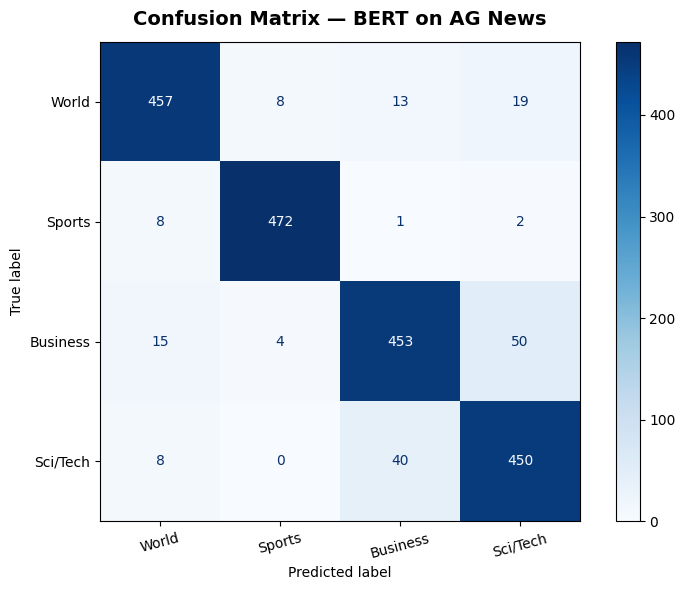

📊 Per-Class Accuracy:
   World       : 91.95%
   Sports      : 97.72%
   Business    : 86.78%
   Sci/Tech    : 90.36%


In [13]:
# ============================================================
# CELL 13 ▸ Detailed Report & Confusion Matrix
# ============================================================

pred_out = trainer.predict(tokenized_test)
y_pred   = np.argmax(pred_out.predictions, axis=-1)
y_true   = pred_out.label_ids

# Per-class classification report
print("=" * 60)
print("📋 CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=label_names, digits=4))

# Confusion matrix
cm  = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names).plot(
    ax=ax, cmap="Blues", colorbar=True, xticks_rotation=15
)
ax.set_title("Confusion Matrix — BERT on AG News", fontsize=14, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# Per-class accuracy
print("📊 Per-Class Accuracy:")
for i, name in enumerate(label_names):
    mask = (y_true == i)
    acc  = accuracy_score(y_true[mask], y_pred[mask])
    print(f"   {name:<12}: {acc*100:.2f}%")

## Step 13 · Training Loss & Accuracy Curves

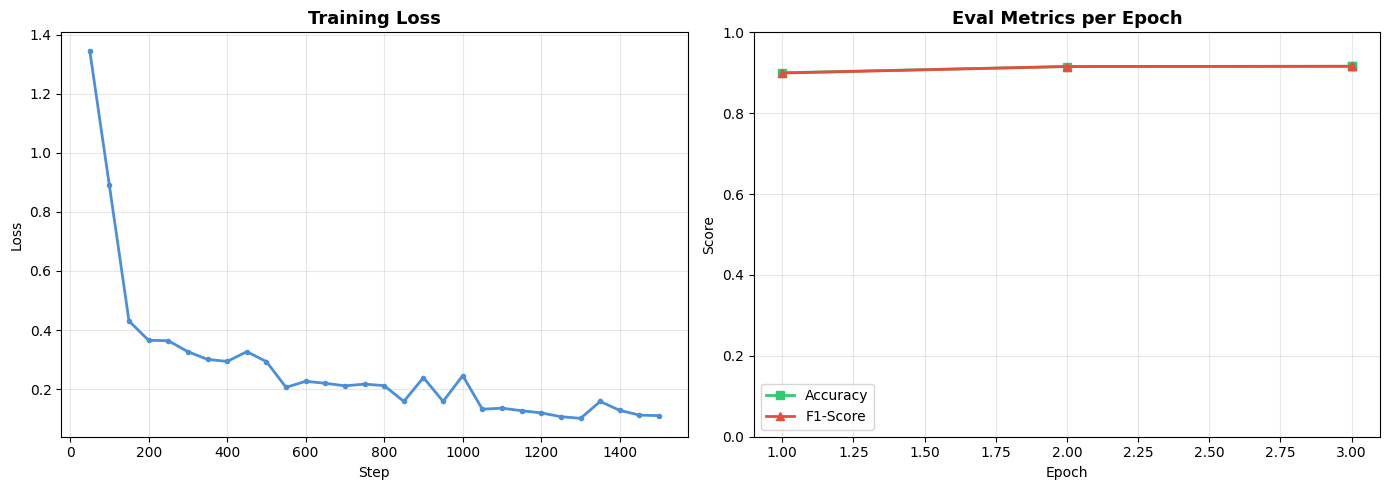

✅ Curves saved!


In [14]:
# ============================================================
# CELL 14 ▸ Training Curves
# ============================================================

log_history = trainer.state.log_history
train_logs  = [e for e in log_history if "loss" in e and "eval_loss" not in e]
eval_logs   = [e for e in log_history if "eval_loss" in e]

if train_logs:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Training loss
    axes[0].plot([e["step"] for e in train_logs],
                 [e["loss"] for e in train_logs],
                 color="#4A90D9", linewidth=2, marker="o", markersize=3)
    axes[0].set_title("Training Loss", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Step"); axes[0].set_ylabel("Loss")
    axes[0].grid(True, alpha=0.3)

    # Eval metrics per epoch
    if eval_logs:
        epochs = [e.get("epoch", i+1) for i, e in enumerate(eval_logs)]
        axes[1].plot(epochs, [e.get("eval_accuracy", 0) for e in eval_logs],
                     color="#2ECC71", linewidth=2, marker="s", label="Accuracy")
        axes[1].plot(epochs, [e.get("eval_f1", 0) for e in eval_logs],
                     color="#E74C3C", linewidth=2, marker="^", label="F1-Score")
        axes[1].set_title("Eval Metrics per Epoch", fontsize=13, fontweight="bold")
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Score")
        axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Curves saved!")

## Step 14 · Sample Predictions on New Headlines

In [15]:
# ============================================================
# CELL 15 ▸ Sample Predictions
# ============================================================

model.eval()
model.to(device)

def predict(text):
    """Classify a single news headline."""
    inputs = tokenizer(text, return_tensors="pt", truncation=True,
                       max_length=128, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        probs = torch.nn.functional.softmax(model(**inputs).logits, dim=-1).squeeze()
    idx = torch.argmax(probs).item()
    return id2label[idx], float(probs[idx]), {id2label[i]: round(float(probs[i]),4) for i in range(4)}

headlines = [
    "NASA discovers new exoplanet with potential for liquid water",
    "Manchester United defeats Chelsea 3-1 in Premier League",
    "Federal Reserve raises interest rates amid inflation fears",
    "Thousands displaced as flooding hits Southeast Asia",
    "Apple unveils iPhone with breakthrough AI features",
    "Scientists develop gene therapy to cure childhood disease",
]

print("=" * 70)
print("🔮 SAMPLE PREDICTIONS")
print("=" * 70)
for i, h in enumerate(headlines, 1):
    label, conf, all_p = predict(h)
    print(f"\n[{i}] {h}")
    print(f"     → {label}  (confidence: {conf*100:.1f}%)")
    print(f"     All: {' | '.join(f'{k}: {v:.3f}' for k,v in all_p.items())}")
print("\n" + "=" * 70)

🔮 SAMPLE PREDICTIONS

[1] NASA discovers new exoplanet with potential for liquid water
     → Sci/Tech  (confidence: 99.4%)
     All: World: 0.003 | Sports: 0.001 | Business: 0.002 | Sci/Tech: 0.994

[2] Manchester United defeats Chelsea 3-1 in Premier League
     → Sports  (confidence: 97.1%)
     All: World: 0.027 | Sports: 0.971 | Business: 0.001 | Sci/Tech: 0.001

[3] Federal Reserve raises interest rates amid inflation fears
     → Business  (confidence: 99.3%)
     All: World: 0.005 | Sports: 0.001 | Business: 0.993 | Sci/Tech: 0.002

[4] Thousands displaced as flooding hits Southeast Asia
     → World  (confidence: 99.7%)
     All: World: 0.997 | Sports: 0.000 | Business: 0.001 | Sci/Tech: 0.001

[5] Apple unveils iPhone with breakthrough AI features
     → Sci/Tech  (confidence: 99.4%)
     All: World: 0.002 | Sports: 0.001 | Business: 0.003 | Sci/Tech: 0.994

[6] Scientists develop gene therapy to cure childhood disease
     → Sci/Tech  (confidence: 97.1%)
     All: World: 0.0

## Step 15 · Save the Fine-Tuned Model

In [16]:
# ============================================================
# CELL 16 ▸ Save Model & Tokenizer
# ============================================================

SAVE_DIR = "./bert-ag-news-final"    # 📝 Change path if needed

model.save_pretrained(SAVE_DIR)      # Saves weights + config
tokenizer.save_pretrained(SAVE_DIR)  # Saves vocab + tokenizer config

print(f"✅ Model saved to: {SAVE_DIR}/")
print("\n📁 Saved files:")
for f in sorted(os.listdir(SAVE_DIR)):
    size = os.path.getsize(os.path.join(SAVE_DIR, f)) / 1e6
    print(f"   {f:<40} ({size:.1f} MB)")

print(f"""
💡 To reload later:
   model     = AutoModelForSequenceClassification.from_pretrained('{SAVE_DIR}')
   tokenizer = AutoTokenizer.from_pretrained('{SAVE_DIR}')
""")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved to: ./bert-ag-news-final/

📁 Saved files:
   config.json                              (0.0 MB)
   model.safetensors                        (438.0 MB)
   tokenizer.json                           (0.7 MB)
   tokenizer_config.json                    (0.0 MB)

💡 To reload later:
   model     = AutoModelForSequenceClassification.from_pretrained('./bert-ag-news-final')
   tokenizer = AutoTokenizer.from_pretrained('./bert-ag-news-final')



## Step 16 · Upload to Hugging Face Hub *(Optional)*
Share your model publicly! You need a free account at [huggingface.co](https://huggingface.co).  
Get your token from: **Settings → Access Tokens → New Token**

In [17]:
# ============================================================
# CELL 17 ▸ Upload to Hugging Face Hub (Optional)
# ============================================================

# ⚠️ Replace these before uncommenting:
# HF_TOKEN    = "hf_YOUR_TOKEN_HERE"        # Your HF access token
# HF_USERNAME = "your-username"             # Your HF username
# REPO_NAME   = "bert-ag-news-classifier"   # Name for the new repo

# from huggingface_hub import login
# login(token=HF_TOKEN)
# model.push_to_hub(f"{HF_USERNAME}/{REPO_NAME}")
# tokenizer.push_to_hub(f"{HF_USERNAME}/{REPO_NAME}")
# print(f"✅ Uploaded → https://huggingface.co/{HF_USERNAME}/{REPO_NAME}")

print("ℹ️  HF Hub upload is commented out.")
print("   Fill in HF_TOKEN and HF_USERNAME above, then uncomment to upload.")

ℹ️  HF Hub upload is commented out.
   Fill in HF_TOKEN and HF_USERNAME above, then uncomment to upload.


## Step 17 · Gradio Interactive Demo
Live demo — type any headline and get an instant classification.  
`share=True` generates a public URL (works in Google Colab).

In [18]:
# ============================================================
# CELL 18 ▸ Gradio Interactive Demo
# ============================================================

import gradio as gr

ICONS = {"World":"🌍 World","Sports":"🏅 Sports","Business":"💼 Business","Sci/Tech":"🔬 Sci/Tech"}

def classify_news(text):
    if not text or not text.strip():
        return {"Enter a headline above": 1.0}
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        probs = torch.nn.functional.softmax(model(**inputs).logits, dim=-1).squeeze()
    return {ICONS[id2label[i]]: float(probs[i]) for i in range(4)}

examples = [
    ["Scientists discover new treatment for Alzheimer's using gene editing"],
    ["LeBron James scores 40 points as Lakers defeat Warriors"],
    ["Fed signals rate cut as inflation cools to 2.1%"],
    ["Earthquake measuring 6.8 strikes coastal Japan"],
    ["OpenAI releases GPT-5 with unprecedented reasoning capabilities"],
    ["Tour de France champion breaks mountain stage record"],
]

demo = gr.Interface(
    fn=classify_news,
    inputs=gr.Textbox(label="📰 News Headline", placeholder="Paste any headline here...", lines=2),
    outputs=gr.Label(label="📊 Category Probabilities", num_top_classes=4),
    title="🤖 News Topic Classifier — BERT (AG News)",
    description="Fine-tuned bert-base-uncased · Categories: 🌍 World | 🏅 Sports | 💼 Business | 🔬 Sci/Tech",
    examples=examples,
    theme=gr.themes.Soft(),
    allow_flagging="never",
)

demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8d7383854a2a117b65.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---

## Project Summary & Insights

### What We Built
A **News Topic Classifier** that fine-tunes `bert-base-uncased` on the **AG News Dataset**
to classify headlines into 4 categories: World · Sports · Business · Sci/Tech.

---

###  Expected Results

| Metric        | Expected Score |
|---------------|----------------|
| Test Accuracy | ~93 – 94%      |
| Weighted F1   | ~93 – 94%      |
| Training Time | ~15 – 25 min (T4 GPU) |

---

###  Key Insights

1. **Transfer learning is powerful** — BERT already understands English; we only teach it topic boundaries.
2. **Even 8K samples are enough** — pre-training gives BERT rich linguistic knowledge to fine-tune from.
3. **Balanced classes = unbiased training** — AG News has exactly 30,000 samples per class.
4. **Business & Sci/Tech overlap** — headlines like *"Apple earnings"* can confuse both classes slightly.
5. **fp16 mixed precision** — halves GPU memory and speeds up training with no accuracy loss.

---

###  Possible Improvements

- Use the **full 120K dataset** for ~1–2% accuracy gain
- Try **DistilBERT** for 40% faster inference with similar accuracy
- Try **RoBERTa** or **DeBERTa** for potentially higher accuracy
- Deploy permanently on **Hugging Face Spaces**

---

###  Skills Demonstrated
✅ NLP with Transformer models (BERT)  
✅ Transfer learning & fine-tuning  
✅ Hugging Face Datasets + Transformers + Trainer API  
✅ Accuracy, F1-Score, Confusion Matrix evaluation  
✅ GPU training in Google Colab  
✅ Model saving & Gradio deployment  

---
*DevelopersHub Corporation · AI/ML Engineering Internship · Task 1 · 2026*